# Who Can Still Afford to Live Here?
## How Remote Work Reshaped Housing Affordability Across the United States


This project analyzes how remote work has influenced migration patterns and rent growth in the Bay Area. Using ACS data, Zillow rent data, and a custom simulation, I estimate how high-income remote workers impact housing markets and evaluate a Dynamic Local Income Tax (DLIT) policy. Results suggest that remote work alone does not explain rent growth patterns in the Bay Area. However, simulation results suggests that if high-income remote workers do relocate, they can meaningfully impact local housing markets, and policies such as DLIT can influence these dynamics. 

### Introduction 

The rise of remote work has reshaped migration patterns across the United States,enabling higher-income remote workers to relocate away from traditional urban job centers to more affordable suburban neighborhoods. This inflow of remote workers can lead to upward pressure on local housing markets, increasing costs and reducing affordability for existing local residents. This dynamic has also generated uneven regional impacts across metropolitan areas.
While some large metropolitan cores experienced slower rent growth or population
decline, surrounding suburban cities face intensified competition for their housing stock. These shifts, commonly referred to as the post-pandemic “Donut Effect”, have led to patterns of displacement, growing concerns towards long-term housing affordability, and increased strain on local infrastructure. Such shifts can also create spillover effects, in which nearby areas experience rent and home price increases even if they are not directly receiving new residents.


In the San Francisco Bay Area, these trends have intensified in suburban
neighborhoods, where an influx of remote workers since the COVID-19 pandemic has
contributed to rising rent and home prices and increased affordability pressures for local residents. This analysis will identify the causal effect of the migration of remote workers from city centers to affordable suburbs on the rate of rent increase. It will also measure the effects of implementing a dynamic local income tax (DLIT) on cities surrounding San Francisco’s CBD by using a custom simulation to mimic household relocation decisions across cities over time. Specificically, we simulate a regional housing market in which households choose locations based on rent, amentities, and tax burdens, while rents adjust endogenously in response to changes in local demand and housing supply constraints. 

Within this framework, I examine whether the introduction of a DLIT policy reduces the incentive for high-income remote workers to relocate from San Francisco to surrounding citues, and whether moderating this inflow helps stabilize rent and housing costs for existing residents. By comparing simulated outcomes with and without the policy interventionk, I assess the extent to which targeted taxation can mitigate afforability pressures associated with remote work-driven migration.

### Data

This analysis combines housing, economic, and remote work data to examine how migration patterns affect rent growth across cities in the San Francisco Bay Area. These datasets capture income levels, housing supply characteristics, rental prices, and remote work prevalence, which together inform both the empirical analysis and simulation model. 

* Economic Data: ACS Selected Economic Characteristics (DP03)
    - Median income by city
    - 5 year estimates

* Housing Supply: ACS Selected Housing Characteristics (DP04)
    - Total number of availible housing units by city
    - 5 year estimates

* Rent Price: Zillow Observed Rent Index (ZORI)
    - Monthly rent by city
    - Jan 2015 - Nov 2025
    - used to compute:
        - rent levels
        - rent growth
        - rent growth acceleration

* Remote Work Share: ACS Sex of Workers by Means of Transporation to Work
    - Number in-office vs work-from-home workers by city 
    - 5 year estimates
    - 2019 & 2023 (2023 was the most recent availible data)
    - used to compute: 
        - remote work share

### Data Cleaning

This section outlines the steps taken to clean, standardize, and merge datasets to ensire consistency across cities and time periods. 

General Cleaning Steps:
- Standardized city names across all datasets for consistent merges
- Filtered datasets to a common set of Bay Area cities to be used throughout the analysis
- Handled missing values by:
    - Dropping cities with insufficient data coverage
    - Removing missing time periods
- Converted all relevant columns to numeric datatypes for analysis

All cleaning steps are reproducible and implemented programmatically in the notebook. 

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import math
import statsmodels.formula.api as sm

In [151]:
cities = ['San Francisco', 'Daly City', 'South San Francisco', 
          'Brisbane', 'Pacifica', 'San Leandro', 'Oakland', 
          'Berkeley', 'Alameda', 'San Bruno', 'San Rafael', 
          'Sausalito', 'Mill Valley']

def geo_area_name(city):
    city_list = []
    for city in cities:
        GAN = f'{city} city, California'
        city_list.append(GAN)
    return city_list
    
geo_area_names = geo_area_name(cities)
geo_area_names

['San Francisco city, California',
 'Daly City city, California',
 'South San Francisco city, California',
 'Brisbane city, California',
 'Pacifica city, California',
 'San Leandro city, California',
 'Oakland city, California',
 'Berkeley city, California',
 'Alameda city, California',
 'San Bruno city, California',
 'San Rafael city, California',
 'Sausalito city, California',
 'Mill Valley city, California']

##### Income

Relevant variables: city name, median household income

In [152]:
med_inc = pd.read_csv('data/Econ_chars (DP03)/econ_char_data.csv')
med_inc.head(5)

/var/folders/4j/njttzsjx355flj2y4dyg94080000gn/T/ipykernel_72982/1285976440.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,128,129,132,133,136,137,140,141,144,145,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,178,179,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,276,290,294,302,306,310,326,338,366,376,424,452,464,474,478,480,482,492,502) have mixed types. Specify dtype option on import or set low_memory=False.
  med_inc = pd.read_csv('data/Econ_cha

,GEO_ID,NAME,DP03_0001E,DP03_0001M,DP03_0002E,DP03_0002M,DP03_0003E,DP03_0003M,DP03_0004E,DP03_0004M,...,DP03_0133PM,DP03_0134PE,DP03_0134PM,DP03_0135PE,DP03_0135PM,DP03_0136PE,DP03_0136PM,DP03_0137PE,DP03_0137PM,Unnamed: 550
0,Geography,Geographic Area Name,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,...,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,NaN
1,1600000US0600135,"Acalanes Ridge CDP, California",977,220,558,197,558,197,508,197,...,6.0,7.2,9.3,0.0,11.7,4.5,7.0,4.6,8.7,NaN
2,1600000US0600156,"Acampo CDP, California",258,260,133,127,133,127,133,127,...,27.7,35.0,26.2,0.0,51.1,0.0,26.8,51.7,7.2,NaN
3,1600000US0600212,"Acton CDP, California",6288,633,3534,445,3508,444,3448,440,...,6.0,7.5,3.9,13.6,13.4,6.3,5.9,19.1,10.4,NaN
4,1600000US0600296,"Adelanto city, California",26690,807,14567,750,14550,754,12865,671,...,3.0,13.8,3.3,17.7,7.4,13.9,3.8,40.9,6.0,NaN


In [153]:
median_cols = med_inc.columns[
    med_inc.iloc[0, :].str.contains('median', case=False, na=False)
]


In [154]:
pd.set_option('display.max_colwidth', None)


new = med_inc.loc[:, median_cols]
new = new.iloc[0, :]
new


DP03_0062E                                   Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)
DP03_0062M                            Margin of Error!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)
DP03_0086E                                              Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Families!!Median family income (dollars)
DP03_0086M                                       Margin of Error!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Families!!Median family income (dollars)
DP03_0090E                               Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Nonfamily households!!Median nonfamily income (dollars)
DP03_0090M                        Margin of Error!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Nonfamily households!!Median nonfamily income (dollars)
DP03_0092E

In [155]:
med_house_inc = med_inc[['GEO_ID', 'NAME', 'DP03_0062E']]
med_house_inc.head()

,GEO_ID,NAME,DP03_0062E
0,Geography,Geographic Area Name,Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)
1,1600000US0600135,"Acalanes Ridge CDP, California",172667
2,1600000US0600156,"Acampo CDP, California",-
3,1600000US0600212,"Acton CDP, California",110000
4,1600000US0600296,"Adelanto city, California",68419


In [156]:
MHI_cities = med_house_inc[med_house_inc['NAME'].isin(geo_area_names)]
MHI_cities = MHI_cities.rename(columns = {'DP03_0062E': 'MEDIAN_HOUSEHOLD_INCOME'})
MHI_cities = MHI_cities[['NAME', 'MEDIAN_HOUSEHOLD_INCOME']]
MHI_cities.head()

,NAME,MEDIAN_HOUSEHOLD_INCOME
11,"Alameda city, California",132015
110,"Berkeley city, California",108558
162,"Brisbane city, California",151593
350,"Daly City city, California",119570
928,"Mill Valley city, California",208466


##### Housing Characteristics

Relevant variables: city name, total housing units

In [157]:
#Housing Characteristics
house_chars = pd.read_csv('data/House_chars (DP04)/house_chars.csv')
house_chars.head(5)

/var/folders/4j/njttzsjx355flj2y4dyg94080000gn/T/ipykernel_72982/4137729081.py:2: DtypeWarning: Columns (2,3,4,5,6,7,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,204,205,206,207,208,209,210,211,212,213,214,215,216,217,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,2

,GEO_ID,NAME,DP04_0001E,DP04_0001M,DP04_0002E,DP04_0002M,DP04_0003E,DP04_0003M,DP04_0004E,DP04_0004M,...,DP04_0139PM,DP04_0140PE,DP04_0140PM,DP04_0141PE,DP04_0141PM,DP04_0142PE,DP04_0142PM,DP04_0143PE,DP04_0143PM,Unnamed: 574
0,Geography,Geographic Area Name,Estimate!!HOUSING OCCUPANCY!!Total housing units,Margin of Error!!HOUSING OCCUPANCY!!Total housing units,Estimate!!HOUSING OCCUPANCY!!Total housing units!!Occupied housing units,Margin of Error!!HOUSING OCCUPANCY!!Total housing units!!Occupied housing units,Estimate!!HOUSING OCCUPANCY!!Total housing units!!Vacant housing units,Margin of Error!!HOUSING OCCUPANCY!!Total housing units!!Vacant housing units,Estimate!!HOUSING OCCUPANCY!!Total housing units!!Homeowner vacancy rate,Margin of Error!!HOUSING OCCUPANCY!!Total housing units!!Homeowner vacancy rate,...,Percent Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!20.0 to 24.9 percent,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!25.0 to 29.9 percent,Percent Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!25.0 to 29.9 percent,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!30.0 to 34.9 percent,Percent Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!30.0 to 34.9 percent,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!35.0 percent or more,Percent Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!35.0 percent or more,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!Not computed,Percent Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!Not computed,NaN
1,1600000US0600135,"Acalanes Ridge CDP, California",422,97,422,97,0,14,0.0,12.9,...,46.7,0.0,34.0,0.0,34.0,49.0,42.4,(X),(X),NaN
2,1600000US0600156,"Acampo CDP, California",133,127,133,127,0,14,0.0,51.1,...,35.7,0.0,35.7,0.0,35.7,100.0,35.7,(X),(X),NaN
3,1600000US0600212,"Acton CDP, California",2887,243,2680,220,207,135,0.0,1.7,...,14.3,0.0,33.3,0.0,33.3,66.7,34.9,(X),(X),NaN
4,1600000US0600296,"Adelanto city, California",9756,430,9192,414,564,208,0.3,0.7,...,5.4,8.7,4.2,4.3,3.1,50.9,7.6,(X),(X),NaN


In [158]:
tot_house_units = house_chars[['GEO_ID', 'NAME', 'DP04_0001E']]
tot_house_units = tot_house_units[tot_house_units['NAME'].isin(geo_area_names)]
tot_house_units.rename(columns = {'DP04_0001E': 'TOTAL_HOUSING_UNITS'}, inplace=True)

tot_house_units = tot_house_units[['NAME', 'TOTAL_HOUSING_UNITS']]
tot_house_units

,NAME,TOTAL_HOUSING_UNITS
11,"Alameda city, California",32129
110,"Berkeley city, California",52112
162,"Brisbane city, California",2101
350,"Daly City city, California",35414
928,"Mill Valley city, California",6353
1032,"Oakland city, California",187847
1069,"Pacifica city, California",14596
1262,"San Bruno city, California",16736
1271,"San Francisco city, California",411542
1280,"San Leandro city, California",32285


##### Zillow Prices

Relevant variables: city name, median rent price (Nov 2025)

In [159]:
#Zillow Rent Prices
zillow = pd.read_csv('data/City_zori_uc_sfrcondomfr_sm_month.csv')
zillow.head(5)

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2015-01-31,2015-02-28,...,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2528.657662,2541.502250,...,3518.974892,3558.949890,3604.291191,3638.289807,3686.378593,3729.248638,3762.565292,3756.746130,3738.977949,3707.812323
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,1770.606343,1783.594043,...,2784.048728,2807.782064,2799.587338,2798.293171,2796.136058,2799.361232,2801.150730,2802.879392,2800.825568,2790.933554
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,1165.774764,1168.255738,...,1549.711960,1558.040240,1563.264943,1564.534390,1555.764528,1555.681724,1554.545956,1558.467173,1550.125772,1542.392993
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,1457.170652,1466.548814,...,2075.425016,2101.650101,2129.151933,2154.201044,2176.898878,2189.997820,2192.318480,2188.548113,2178.714403,2173.048749
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,974.922787,978.354567,...,1369.508106,1379.117923,1381.116615,1381.756524,1379.760886,1383.779397,1379.213404,1372.251719,1360.565310,1350.560647


In [160]:
rent_price = zillow[(zillow['RegionName'].isin(cities)) & (zillow['State'] == 'CA')]
rent_price = rent_price[['RegionID', 'RegionName', 'RegionType', 'State', '2025-11-30']]
rent_price.rename(columns = {'2025-11-30': 'NOV_2025_MEDIAN_RENT_PRICE'}, inplace=True)
rent_price = rent_price[['RegionName', 'NOV_2025_MEDIAN_RENT_PRICE']]
rent_price = rent_price.rename(columns = {'RegionName': 'NAME'})
rent_price

,NAME,NOV_2025_MEDIAN_RENT_PRICE
17,San Francisco,3679.658922
51,Oakland,2457.896337
347,Berkeley,2920.797835
387,San Leandro,2387.844055
424,Daly City,2729.278102
740,San Rafael,3117.600119
791,Alameda,2775.369222
856,South San Francisco,3532.924434
1389,San Bruno,2929.895238
1559,Pacifica,3560.822222


##### Remote Work Share (proxy for remote-capable workforce concentration)

Relevant variables: city name, total in-office workers, total work-from-home workers

In [161]:
#remote work data -- 2019 & 2023
folder = 'data/Remote_work_cali_B08006/'
wfh_tables = ['wfh2019.csv', 'wfh2023.csv']
dfs = {}
for table in wfh_tables:
    year = int(table.replace('wfh', '').replace('.csv', ''))
    path = folder + table

    df = pd.read_csv(path)
    df['year'] = year
    dfs[f"wfh_{year}"] = df


In [162]:
cleaned_dfs = {}
for name, df in dfs.items():
    df = df[df['NAME'].isin(geo_area_names)].copy()
    df = df.rename(columns = {'B08006_017E': 'tot_wfh', 'B08006_001E' : 'tot_work'})
    df = df[['NAME','tot_work', 'tot_wfh']]

    df['tot_work'] = pd.to_numeric(df['tot_work'], errors='coerce')
    df['tot_wfh'] = pd.to_numeric(df['tot_wfh'], errors='coerce')

    year = int(name.split('_')[1])
    df['year'] = year

    df['remote_share'] = df['tot_wfh'] / df['tot_work']

    cleaned_dfs[name] = df
cleaned_dfs


{'wfh_2019':                                       NAME  tot_work  tot_wfh  year  \
 11                Alameda city, California     41223     2993  2019   
 105              Berkeley city, California     61310     6569  2019   
 157              Brisbane city, California      2636      195  2019   
 334             Daly City city, California     58872     1394  2019   
 874           Mill Valley city, California      6711     1045  2019   
 974               Oakland city, California    219406    14659  2019   
 1005             Pacifica city, California     21248     1036  2019   
 1184            San Bruno city, California     24082      636  2019   
 1193        San Francisco city, California    512455    33810  2019   
 1202          San Leandro city, California     45810     1885  2019   
 1214           San Rafael city, California     29038     3124  2019   
 1238            Sausalito city, California      3868      563  2019   
 1296  South San Francisco city, California     3720

In [ ]:
wfh_2019 = cleaned_dfs['wfh_2019']
wfh_2019 = wfh_2019.rename(columns={"remote_share": "remote_share_2019"})
wfh_2023 = cleaned_dfs['wfh_2023']
wfh_2023 = wfh_2023.rename(columns={"remote_share": "remote_share_2023"})

remote_work = wfh_2023.merge(wfh_2019, on='NAME', suffixes=('_2023', '_2019'))
remote_work = remote_work[['NAME', 'remote_share_2019', 'remote_share_2023']]
remote_work

,NAME,remote_share_2019,remote_share_2023
0,"Alameda city, California",0.072605,0.281149
1,"Berkeley city, California",0.107144,0.324777
2,"Brisbane city, California",0.073976,0.244493
3,"Daly City city, California",0.023678,0.127859
4,"Mill Valley city, California",0.155714,0.372365
5,"Oakland city, California",0.066812,0.234345
6,"Pacifica city, California",0.048758,0.211772
7,"San Bruno city, California",0.026410,0.167543
8,"San Francisco city, California",0.065977,0.274570
9,"San Leandro city, California",0.041148,0.127801


##### Merging Tables

Final Dataset Construction
- Merged all datasets into a single master table by city
- Ensured alignment across:
    - Time periods
    - Geographic units
    - Variable formats
- Created affordability metrics to be used in analysis and simulation
    - Rent-to-income
    - Monthly rent share of income
    - Remote work growth
    - Baseline & post rent growth
    - Rent growth acceleration
    - Log income
    - Monthly income

In [214]:
def clean_city_names(df):
    df['NAME'] = (
        df['NAME']
        .str.replace(' city, California', '', regex=False)
    )
    df.rename(columns={'NAME': 'city'}, inplace=True)
    return df

MHI_cities = clean_city_names(MHI_cities)
tot_house_units = clean_city_names(tot_house_units)
rent_price = clean_city_names(rent_price)
remote_work = clean_city_names(remote_work)

KeyError: 'NAME'

In [165]:
MHI_cities.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 11 to 1378
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   city                     13 non-null     object
 1   MEDIAN_HOUSEHOLD_INCOME  13 non-null     object
dtypes: object(2)
memory usage: 312.0+ bytes


In [166]:
tot_house_units.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 11 to 1378
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 13 non-null     object
 1   TOTAL_HOUSING_UNITS  13 non-null     object
dtypes: object(2)
memory usage: 312.0+ bytes


In [167]:
rent_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 17 to 3151
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        12 non-null     object 
 1   NOV_2025_MEDIAN_RENT_PRICE  12 non-null     float64
dtypes: float64(1), object(1)
memory usage: 288.0+ bytes


In [168]:
remote_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               13 non-null     object 
 1   remote_share_2019  13 non-null     float64
 2   remote_share_2023  13 non-null     float64
dtypes: float64(2), object(1)
memory usage: 444.0+ bytes


In [169]:
merged_table = MHI_cities.merge(tot_house_units, on = 'city', how = 'outer')
merged_table = merged_table.merge(rent_price, left_on = 'city', right_on = 'city', how = 'outer')
merged_table = merged_table.merge(remote_work, left_on = 'city', right_on = 'city', how = 'outer')
merged_table.dropna(inplace=True) #cities with unreliable rental market data were excluded
merged_table

,city,MEDIAN_HOUSEHOLD_INCOME,TOTAL_HOUSING_UNITS,NOV_2025_MEDIAN_RENT_PRICE,remote_share_2019,remote_share_2023
0,Alameda,132015,32129,2775.369222,0.072605,0.281149
1,Berkeley,108558,52112,2920.797835,0.107144,0.324777
3,Daly City,119570,35414,2729.278102,0.023678,0.127859
4,Mill Valley,208466,6353,3949.851852,0.155714,0.372365
5,Oakland,97369,187847,2457.896337,0.066812,0.234345
6,Pacifica,156819,14596,3560.822222,0.048758,0.211772
7,San Bruno,135976,16736,2929.895238,0.026410,0.167543
8,San Francisco,141446,411542,3679.658922,0.065977,0.274570
9,San Leandro,98063,32285,2387.844055,0.041148,0.127801
10,San Rafael,109317,24212,3117.600119,0.107583,0.228831


In [170]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 12
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        12 non-null     object 
 1   MEDIAN_HOUSEHOLD_INCOME     12 non-null     object 
 2   TOTAL_HOUSING_UNITS         12 non-null     object 
 3   NOV_2025_MEDIAN_RENT_PRICE  12 non-null     float64
 4   remote_share_2019           12 non-null     float64
 5   remote_share_2023           12 non-null     float64
dtypes: float64(3), object(3)
memory usage: 672.0+ bytes


In [171]:
merged_table['MEDIAN_HOUSEHOLD_INCOME'] = merged_table['MEDIAN_HOUSEHOLD_INCOME'].astype('int64')
merged_table['TOTAL_HOUSING_UNITS'] = merged_table['TOTAL_HOUSING_UNITS'].astype('int64')
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 12
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        12 non-null     object 
 1   MEDIAN_HOUSEHOLD_INCOME     12 non-null     int64  
 2   TOTAL_HOUSING_UNITS         12 non-null     int64  
 3   NOV_2025_MEDIAN_RENT_PRICE  12 non-null     float64
 4   remote_share_2019           12 non-null     float64
 5   remote_share_2023           12 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 672.0+ bytes


In [172]:
merged_table 

,city,MEDIAN_HOUSEHOLD_INCOME,TOTAL_HOUSING_UNITS,NOV_2025_MEDIAN_RENT_PRICE,remote_share_2019,remote_share_2023
0,Alameda,132015,32129,2775.369222,0.072605,0.281149
1,Berkeley,108558,52112,2920.797835,0.107144,0.324777
3,Daly City,119570,35414,2729.278102,0.023678,0.127859
4,Mill Valley,208466,6353,3949.851852,0.155714,0.372365
5,Oakland,97369,187847,2457.896337,0.066812,0.234345
6,Pacifica,156819,14596,3560.822222,0.048758,0.211772
7,San Bruno,135976,16736,2929.895238,0.026410,0.167543
8,San Francisco,141446,411542,3679.658922,0.065977,0.274570
9,San Leandro,98063,32285,2387.844055,0.041148,0.127801
10,San Rafael,109317,24212,3117.600119,0.107583,0.228831


In [173]:
#affordability_metrics
merged_table['RENT_TO_INCOME_RATIO'] = merged_table['NOV_2025_MEDIAN_RENT_PRICE'] * 12 / merged_table['MEDIAN_HOUSEHOLD_INCOME']
merged_table['MONTLY_RENT_SHARE'] = merged_table['NOV_2025_MEDIAN_RENT_PRICE'] / (merged_table['MEDIAN_HOUSEHOLD_INCOME'] / 12)

merged_table['remote_work_growth'] = merged_table['remote_share_2023'] - merged_table['remote_share_2019']

merged_table.drop(columns = ['remote_share_2023'], inplace=True)

merged_table.head()

,city,MEDIAN_HOUSEHOLD_INCOME,TOTAL_HOUSING_UNITS,NOV_2025_MEDIAN_RENT_PRICE,remote_share_2019,RENT_TO_INCOME_RATIO,MONTLY_RENT_SHARE,remote_work_growth
0,Alameda,132015,32129,2775.369222,0.072605,0.252278,0.252278,0.208544
1,Berkeley,108558,52112,2920.797835,0.107144,0.322865,0.322865,0.217633
3,Daly City,119570,35414,2729.278102,0.023678,0.273909,0.273909,0.104180
4,Mill Valley,208466,6353,3949.851852,0.155714,0.227367,0.227367,0.216651
5,Oakland,97369,187847,2457.896337,0.066812,0.302917,0.302917,0.167533


In [174]:
#rent growth data
rent_change = zillow[(zillow['RegionName'].isin(cities)) & (zillow['State'] == 'CA')]

rent_change.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2015-01-31,2015-02-28,...,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30
17,20330,17,San Francisco,city,CA,CA,"San Francisco-Oakland-Berkeley, CA",San Francisco County,2968.664424,2984.355243,...,3336.677934,3373.333369,3420.483020,3461.619972,3515.260452,3559.031387,3611.154560,3652.170691,3678.181476,3679.658922
51,13072,51,Oakland,city,CA,CA,"San Francisco-Oakland-Berkeley, CA",Alameda County,1734.158017,1754.783441,...,2382.830915,2400.266657,2410.140965,2426.047758,2432.972542,2443.752970,2462.291466,2472.338887,2471.899767,2457.896337
347,16992,351,Berkeley,city,CA,CA,"San Francisco-Oakland-Berkeley, CA",Alameda County,NaN,NaN,...,2898.664356,2923.963024,2955.149391,2935.247034,2932.072097,2941.070651,2956.230031,2971.571103,2952.034244,2920.797835
387,13698,391,San Leandro,city,CA,CA,"San Francisco-Oakland-Berkeley, CA",Alameda County,NaN,NaN,...,2362.672763,2348.511564,2346.627023,2348.488017,2362.574228,2366.155327,2382.106715,2395.868574,2384.931375,2387.844055
424,31163,428,Daly City,city,CA,CA,"San Francisco-Oakland-Berkeley, CA",San Mateo County,NaN,NaN,...,2626.550865,2634.158371,2660.077011,2685.236440,2713.700424,2695.888494,2700.452330,2712.112843,2723.112207,2729.278102


In [175]:
date_cols = [c for c in rent_change.columns if c[:4].isdigit()]
rent_long = rent_change.melt(
    id_vars=['RegionName'],
    value_vars=date_cols,
    var_name='Date',
    value_name='Median_Rent_Price')
rent_long['Date'] = pd.to_datetime(rent_long['Date'])
rent_long.head()


,RegionName,Date,Median_Rent_Price
0,San Francisco,2015-01-31,2968.664424
1,Oakland,2015-01-31,1734.158017
2,Berkeley,2015-01-31,NaN
3,San Leandro,2015-01-31,NaN
4,Daly City,2015-01-31,NaN


In [176]:
rent_long = rent_long.sort_values(by=['RegionName', 'Date'])
rent_long = rent_long[(rent_long['Date'] >= '2019-01-31') & (rent_long['Date'] <= '2025-11-30')]
rows_with_na = rent_long[rent_long.isna().any(axis=1)]
rows_with_na

,RegionName,Date,Median_Rent_Price
862,Mill Valley,2020-12-31,NaN
705,Pacifica,2019-11-30,NaN
804,San Francisco,2020-08-31,NaN
816,San Francisco,2020-09-30,NaN
1175,Sausalito,2023-02-28,NaN


In [177]:
rent_long

,RegionName,Date,Median_Rent_Price
582,Alameda,2019-01-31,2394.175048
594,Alameda,2019-02-28,2408.097001
606,Alameda,2019-03-31,2409.209915
618,Alameda,2019-04-30,2415.501421
630,Alameda,2019-05-31,2428.559287
...,...,...,...
1519,South San Francisco,2025-07-31,3597.218084
1531,South San Francisco,2025-08-31,3534.747162
1543,South San Francisco,2025-09-30,3530.807685
1555,South San Francisco,2025-10-31,3532.239211


In [178]:
rent_long['log_rent'] = np.log(rent_long['Median_Rent_Price'])
rent_long['monthly_growth'] = rent_long.groupby('RegionName')['log_rent'].diff()
rent_long = rent_long.dropna(subset=['monthly_growth'])

rent_long

,RegionName,Date,Median_Rent_Price,log_rent,monthly_growth
594,Alameda,2019-02-28,2408.097001,7.786592,0.005798
606,Alameda,2019-03-31,2409.209915,7.787054,0.000462
618,Alameda,2019-04-30,2415.501421,7.789662,0.002608
630,Alameda,2019-05-31,2428.559287,7.795053,0.005391
642,Alameda,2019-06-30,2452.184229,7.804734,0.009681
...,...,...,...,...,...
1519,South San Francisco,2025-07-31,3597.218084,8.187916,-0.012063
1531,South San Francisco,2025-08-31,3534.747162,8.170397,-0.017519
1543,South San Francisco,2025-09-30,3530.807685,8.169282,-0.001115
1555,South San Francisco,2025-10-31,3532.239211,8.169687,0.000405


In [179]:
rent_long['period'] = np.where(
    (rent_long['Date'] >= '2019-01-31') & (rent_long['Date'] <= '2020-02-29'),
    'baseline',
    np.where(
        (rent_long['Date'] >= '2020-03-31') & (rent_long['Date'] <= '2025-11-30'),
        'post',
        np.nan))
rent_long = rent_long.dropna(subset=['monthly_growth', 'period'])

rent_long

/var/folders/4j/njttzsjx355flj2y4dyg94080000gn/T/ipykernel_72982/2737421218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rent_long['period'] = np.where(


,RegionName,Date,Median_Rent_Price,log_rent,monthly_growth,period
594,Alameda,2019-02-28,2408.097001,7.786592,0.005798,baseline
606,Alameda,2019-03-31,2409.209915,7.787054,0.000462,baseline
618,Alameda,2019-04-30,2415.501421,7.789662,0.002608,baseline
630,Alameda,2019-05-31,2428.559287,7.795053,0.005391,baseline
642,Alameda,2019-06-30,2452.184229,7.804734,0.009681,baseline
...,...,...,...,...,...,...
1519,South San Francisco,2025-07-31,3597.218084,8.187916,-0.012063,post
1531,South San Francisco,2025-08-31,3534.747162,8.170397,-0.017519,post
1543,South San Francisco,2025-09-30,3530.807685,8.169282,-0.001115,post
1555,South San Francisco,2025-10-31,3532.239211,8.169687,0.000405,post


In [180]:
growth = rent_long.groupby(['RegionName', 'period'])['monthly_growth'].mean().reset_index()
growth['annualized_growth'] = growth['monthly_growth'] * 12

growth

,RegionName,period,monthly_growth,annualized_growth
0,Alameda,baseline,0.001708,0.020492
1,Alameda,post,0.001819,0.021834
2,Berkeley,baseline,0.001930,0.023162
3,Berkeley,post,0.000970,0.011641
4,Daly City,baseline,0.000615,0.007377
5,Daly City,post,0.001799,0.021588
6,Mill Valley,baseline,0.007425,0.089103
7,Mill Valley,post,0.002887,0.034643
8,Oakland,baseline,0.001387,0.016638
9,Oakland,post,0.000167,0.002000


In [181]:
growth_pivot = growth.pivot(index='RegionName', columns='period', values='annualized_growth').reset_index()
growth_pivot

period,RegionName,baseline,post
0,Alameda,0.020492,0.021834
1,Berkeley,0.023162,0.011641
2,Daly City,0.007377,0.021588
3,Mill Valley,0.089103,0.034643
4,Oakland,0.016638,0.002000
5,Pacifica,0.042154,0.022561
6,San Bruno,0.016394,0.020552
7,San Francisco,0.017876,0.034017
8,San Leandro,0.038956,0.023865
9,San Rafael,0.051591,0.032045


In [182]:
growth_pivot['rent_growth_acceleration'] = growth_pivot['post'] - growth_pivot['baseline']
growth_pivot.sort_values(by='rent_growth_acceleration', ascending=False)


period,RegionName,baseline,post,rent_growth_acceleration
7,San Francisco,0.017876,0.034017,0.016142
2,Daly City,0.007377,0.021588,0.014211
6,San Bruno,0.016394,0.020552,0.004157
0,Alameda,0.020492,0.021834,0.001342
11,South San Francisco,0.023075,0.017100,-0.005975
1,Berkeley,0.023162,0.011641,-0.011521
4,Oakland,0.016638,0.002000,-0.014638
8,San Leandro,0.038956,0.023865,-0.015091
9,San Rafael,0.051591,0.032045,-0.019546
5,Pacifica,0.042154,0.022561,-0.019593


In [183]:
master = merged_table.merge(growth_pivot, left_on='city', right_on='RegionName', how='outer')
master.drop(columns=['RegionName'], inplace=True)
master.rename(columns={ 
                       'MEDIAN_HOUSEHOLD_INCOME': 'median_household_income',
                       'TOTAL_HOUSING_UNITS': 'total_housing_units',
                        'NOV_2025_MEDIAN_RENT_PRICE': 'nov_2025_median_rent_price', 
                        'RENT_TO_INCOME_RATIO': 'rent_to_income',
                        'MONTLY_RENT_SHARE': 'monthly_rent_share', 
                        'baseline': 'baseline_rent_growth', 
                        'post': 'post_rent_growth'}, inplace=True)
master

,city,median_household_income,total_housing_units,nov_2025_median_rent_price,remote_share_2019,rent_to_income,monthly_rent_share,remote_work_growth,baseline_rent_growth,post_rent_growth,rent_growth_acceleration
0,Alameda,132015,32129,2775.369222,0.072605,0.252278,0.252278,0.208544,0.020492,0.021834,0.001342
1,Berkeley,108558,52112,2920.797835,0.107144,0.322865,0.322865,0.217633,0.023162,0.011641,-0.011521
2,Daly City,119570,35414,2729.278102,0.023678,0.273909,0.273909,0.104180,0.007377,0.021588,0.014211
3,Mill Valley,208466,6353,3949.851852,0.155714,0.227367,0.227367,0.216651,0.089103,0.034643,-0.054460
4,Oakland,97369,187847,2457.896337,0.066812,0.302917,0.302917,0.167533,0.016638,0.002000,-0.014638
5,Pacifica,156819,14596,3560.822222,0.048758,0.272479,0.272479,0.163014,0.042154,0.022561,-0.019593
6,San Bruno,135976,16736,2929.895238,0.026410,0.258566,0.258566,0.141133,0.016394,0.020552,0.004157
7,San Francisco,141446,411542,3679.658922,0.065977,0.312175,0.312175,0.208593,0.017876,0.034017,0.016142
8,San Leandro,98063,32285,2387.844055,0.041148,0.292201,0.292201,0.086653,0.038956,0.023865,-0.015091
9,San Rafael,109317,24212,3117.600119,0.107583,0.342227,0.342227,0.121248,0.051591,0.032045,-0.019546


In [184]:
master['log_income'] = np.log(master['median_household_income'])

In [185]:
master['monthly_income'] = master['median_household_income'] / 12

In [186]:
master

,city,median_household_income,total_housing_units,nov_2025_median_rent_price,remote_share_2019,rent_to_income,monthly_rent_share,remote_work_growth,baseline_rent_growth,post_rent_growth,rent_growth_acceleration,log_income,monthly_income
0,Alameda,132015,32129,2775.369222,0.072605,0.252278,0.252278,0.208544,0.020492,0.021834,0.001342,11.790671,11001.250000
1,Berkeley,108558,52112,2920.797835,0.107144,0.322865,0.322865,0.217633,0.023162,0.011641,-0.011521,11.595040,9046.500000
2,Daly City,119570,35414,2729.278102,0.023678,0.273909,0.273909,0.104180,0.007377,0.021588,0.014211,11.691657,9964.166667
3,Mill Valley,208466,6353,3949.851852,0.155714,0.227367,0.227367,0.216651,0.089103,0.034643,-0.054460,12.247531,17372.166667
4,Oakland,97369,187847,2457.896337,0.066812,0.302917,0.302917,0.167533,0.016638,0.002000,-0.014638,11.486263,8114.083333
5,Pacifica,156819,14596,3560.822222,0.048758,0.272479,0.272479,0.163014,0.042154,0.022561,-0.019593,11.962848,13068.250000
6,San Bruno,135976,16736,2929.895238,0.026410,0.258566,0.258566,0.141133,0.016394,0.020552,0.004157,11.820234,11331.333333
7,San Francisco,141446,411542,3679.658922,0.065977,0.312175,0.312175,0.208593,0.017876,0.034017,0.016142,11.859673,11787.166667
8,San Leandro,98063,32285,2387.844055,0.041148,0.292201,0.292201,0.086653,0.038956,0.023865,-0.015091,11.493365,8171.916667
9,San Rafael,109317,24212,3117.600119,0.107583,0.342227,0.342227,0.121248,0.051591,0.032045,-0.019546,11.602007,9109.750000


### Exploratory Data Analysis (EDA)

This section explores patterns in rent growth, housing supply, income, and remote work across Bay Area cities. The goal is to identify relationships that inform the regression analysis and simulation design. 

##### Rent Trends Over Time

In [187]:
zillow = zillow[(zillow['RegionName'].isin(cities)) & (zillow['State'] == 'CA')]
zillow = zillow.rename(columns={'RegionName': 'city'})

cols_to_keep = ['city']
for col in zillow.columns:
    try:
        date = pd.to_datetime(col, errors='coerce')
        if date >= pd.to_datetime('2019-01-31') and date <= pd.to_datetime('2025-11-30'):
            cols_to_keep.append(col)
    except:
        cols_to_keep.append(col)
zillow = zillow[cols_to_keep]
zillow



,city,2019-01-31,2019-02-28,2019-03-31,2019-04-30,2019-05-31,2019-06-30,2019-07-31,2019-08-31,2019-09-30,...,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30
17,San Francisco,3336.679076,3345.868651,3360.898949,3365.251242,3380.033092,3399.383427,3429.436685,3437.659914,3427.463929,...,3336.677934,3373.333369,3420.483020,3461.619972,3515.260452,3559.031387,3611.154560,3652.170691,3678.181476,3679.658922
51,Oakland,2386.382236,2375.173502,2385.183562,2385.419012,2414.543038,2434.662256,2464.764023,2469.077819,2470.420105,...,2382.830915,2400.266657,2410.140965,2426.047758,2432.972542,2443.752970,2462.291466,2472.338887,2471.899767,2457.896337
347,Berkeley,2663.996111,2678.341732,2719.524723,2740.162218,2733.570286,2734.744541,2732.150809,2742.007129,2723.014751,...,2898.664356,2923.963024,2955.149391,2935.247034,2932.072097,2941.070651,2956.230031,2971.571103,2952.034244,2920.797835
387,San Leandro,1995.636541,2014.246617,2028.022756,2036.313713,2039.702564,2055.814497,2062.245955,2068.824673,2085.960853,...,2362.672763,2348.511564,2346.627023,2348.488017,2362.574228,2366.155327,2382.106715,2395.868574,2384.931375,2387.844055
424,Daly City,2391.482140,2386.662789,2387.428320,2390.512703,2444.554774,2437.243081,2451.318460,2409.555235,2469.460042,...,2626.550865,2634.158371,2660.077011,2685.236440,2713.700424,2695.888494,2700.452330,2712.112843,2723.112207,2729.278102
740,San Rafael,2452.022814,2476.883046,2501.281440,2519.636394,2540.889904,2555.990583,2587.750632,2603.690838,2616.645069,...,2990.343687,3027.771247,3059.237599,3133.812895,3160.067757,3157.092249,3169.501773,3172.491965,3175.070776,3117.600119
791,Alameda,2394.175048,2408.097001,2409.209915,2415.501421,2428.559287,2452.184229,2464.742909,2453.448799,2452.896041,...,2716.122269,2725.225094,2733.757150,2744.069550,2745.054966,2740.413016,2742.658131,2756.699292,2769.837340,2775.369222
856,South San Francisco,3123.031679,3125.181611,3140.282068,3159.780472,3172.638528,3202.990735,3213.464671,3227.537909,3198.066970,...,3409.861149,3514.569739,3586.926504,3645.606715,3640.872621,3597.218084,3534.747162,3530.807685,3532.239211,3532.924434
1389,San Bruno,2557.510646,2561.554346,2566.748832,2562.129922,2583.245139,2603.051850,2608.131623,2635.004744,2625.570410,...,2767.158378,2755.054766,2777.985488,2809.058901,2861.208402,2866.010292,2854.536434,2862.409855,2884.148776,2929.895238
1559,Pacifica,3138.478963,3121.066447,3144.935438,3082.498397,3088.705267,3088.441682,3035.857878,3130.314877,3151.038819,...,3265.586238,3321.264582,3344.127270,3417.099212,3447.271079,3503.553290,3531.918192,3524.418056,3559.002307,3560.822222


In [188]:
zillow_long = zillow.melt(
    id_vars=['city'],
    var_name='Date',
    value_name='Median_Rent_Price')
zillow_long['Date'] = pd.to_datetime(zillow_long['Date'])
zillow_long

,city,Date,Median_Rent_Price
0,San Francisco,2019-01-31,3336.679076
1,Oakland,2019-01-31,2386.382236
2,Berkeley,2019-01-31,2663.996111
3,San Leandro,2019-01-31,1995.636541
4,Daly City,2019-01-31,2391.482140
...,...,...,...
991,South San Francisco,2025-11-30,3532.924434
992,San Bruno,2025-11-30,2929.895238
993,Pacifica,2025-11-30,3560.822222
994,Mill Valley,2025-11-30,3949.851852


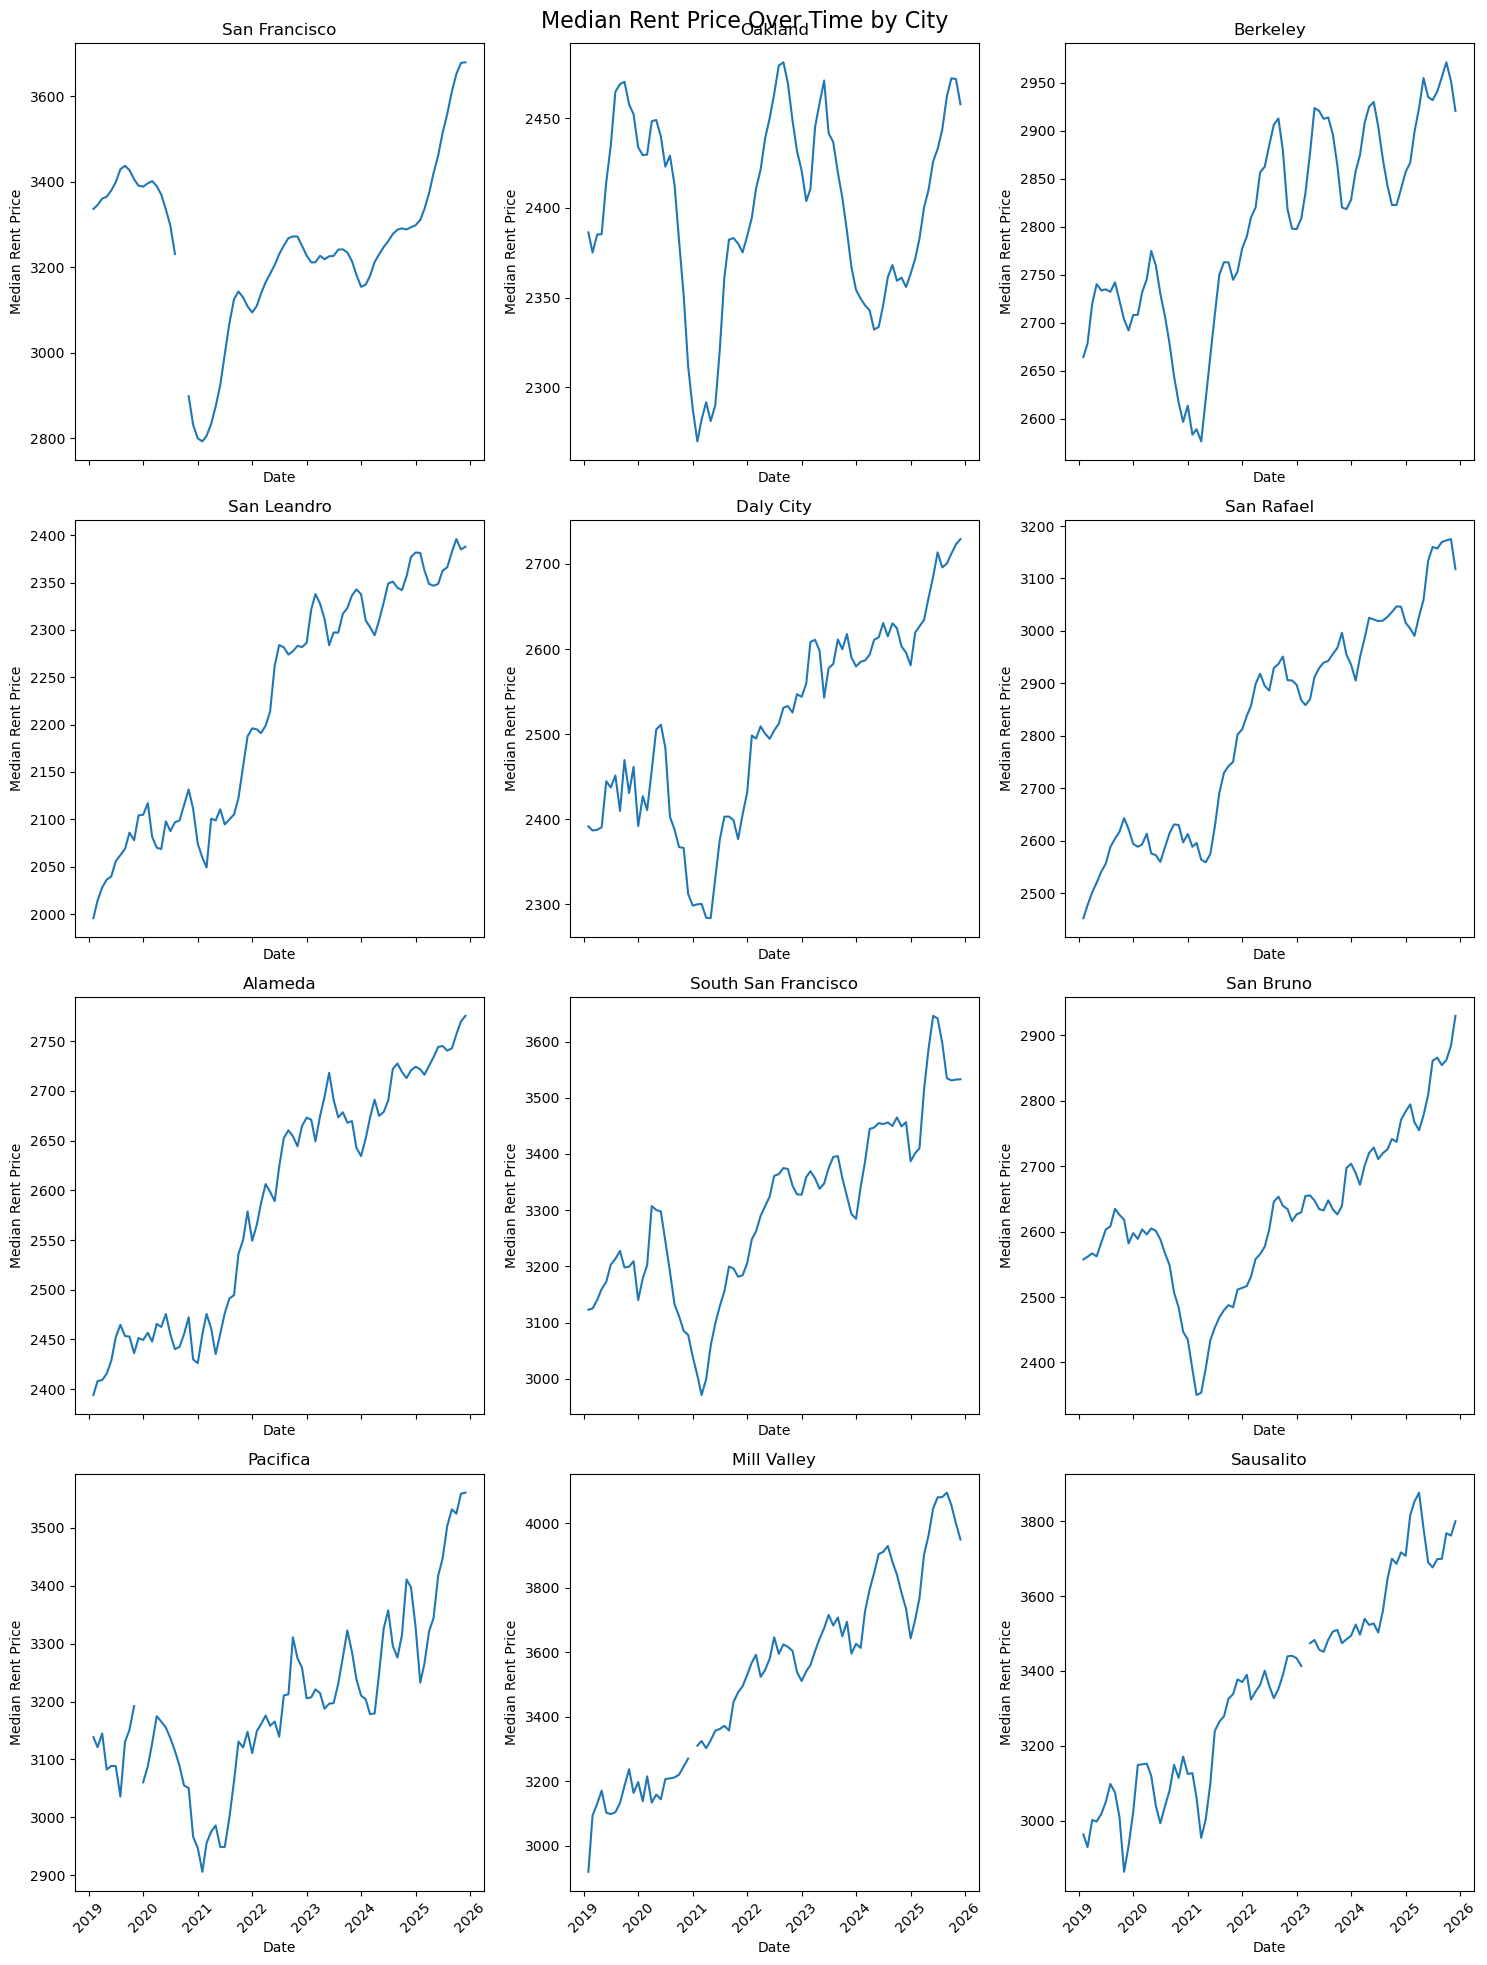

In [189]:
cities = zillow_long['city'].unique()
n_cities = len(cities)

cols = 3
rows = math.ceil(n_cities / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), sharex=True)
axes = axes.flatten()

for i, city in enumerate(cities):
    city_data = zillow_long[zillow_long['city'] == city]
    axes[i].plot(city_data['Date'], city_data['Median_Rent_Price'])
    axes[i].set_title(city)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Median Rent Price')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Median Rent Price Over Time by City', fontsize=16)
plt.tight_layout()
plt.show()

Across every city, rent trends show a dip in median price around 2020 (when COVID-19 began), then a significant growth in the years following. 

##### Rent Growth Acceleration Pre vs Post COVID-19

In [190]:
zillow_long['rent_growth'] = zillow_long.groupby('city')['Median_Rent_Price'].pct_change() * 100
zillow_long.dropna(subset = ['rent_growth'], inplace=True)
zillow_long

/var/folders/4j/njttzsjx355flj2y4dyg94080000gn/T/ipykernel_72982/1585869311.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  zillow_long['rent_growth'] = zillow_long.groupby('city')['Median_Rent_Price'].pct_change() * 100


,city,Date,Median_Rent_Price,rent_growth
12,San Francisco,2019-02-28,3345.868651,0.275411
13,Oakland,2019-02-28,2375.173502,-0.469696
14,Berkeley,2019-02-28,2678.341732,0.538500
15,San Leandro,2019-02-28,2014.246617,0.932538
16,Daly City,2019-02-28,2386.662789,-0.201522
...,...,...,...,...
991,South San Francisco,2025-11-30,3532.924434,0.019399
992,San Bruno,2025-11-30,2929.895238,1.586134
993,Pacifica,2025-11-30,3560.822222,0.051136
994,Mill Valley,2025-11-30,3949.851852,-1.229762


In [191]:
pre = zillow_long[(zillow_long['Date'] >= '2019-01-01') & (zillow_long['Date'] < '2020-03-01')]
post = zillow_long[zillow_long['Date'] >= '2020-03-01']

pre_growth = pre.groupby('city')['rent_growth'].mean()
post_growth = post.groupby('city')['rent_growth'].mean()

acceleration = (post_growth - pre_growth).reset_index()
acceleration.columns = ['city', 'rent_acceleration']

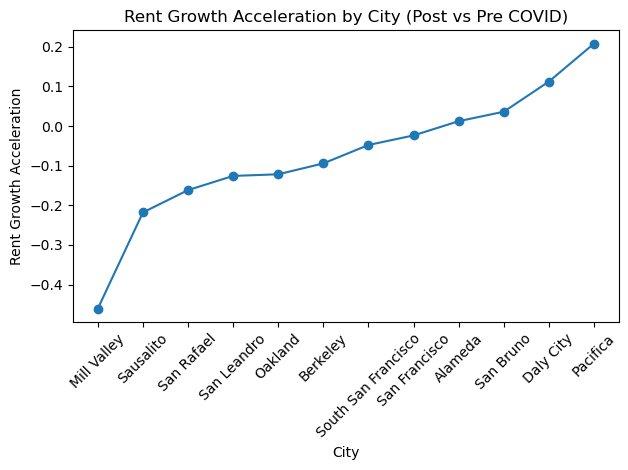

In [192]:
acceleration = acceleration.sort_values('rent_acceleration')

plt.figure()
plt.plot(acceleration['city'], acceleration['rent_acceleration'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('Rent Growth Acceleration')
plt.title('Rent Growth Acceleration by City (Post vs Pre COVID)')
plt.tight_layout()
plt.show()

##### Remote Work Share 2019 vs 2025

In [193]:
remote_work = remote_work.drop(2)
remote_work

,city,remote_share_2019,remote_share_2023
0,Alameda,0.072605,0.281149
1,Berkeley,0.107144,0.324777
3,Daly City,0.023678,0.127859
4,Mill Valley,0.155714,0.372365
5,Oakland,0.066812,0.234345
6,Pacifica,0.048758,0.211772
7,San Bruno,0.026410,0.167543
8,San Francisco,0.065977,0.274570
9,San Leandro,0.041148,0.127801
10,San Rafael,0.107583,0.228831


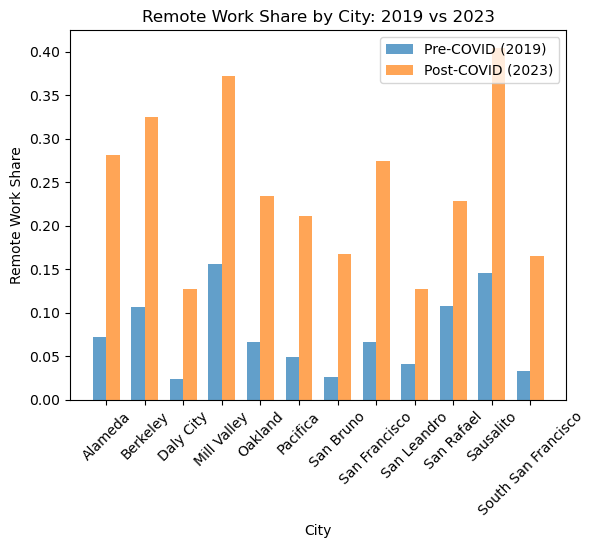

In [194]:
x = np.arange(len(remote_work['city']))
width = 0.35

plt.figure()

plt.bar( x - width/2, remote_work['remote_share_2019'], width, label='Pre-COVID (2019)', alpha=0.7)
plt.bar( x + width/2, remote_work['remote_share_2023'], width, label='Post-COVID (2023)', alpha=0.7)
plt.xticks(x, remote_work['city'], rotation=45)
plt.xlabel('City')
plt.ylabel('Remote Work Share')
plt.title('Remote Work Share by City: 2019 vs 2023')
plt.legend()

Across every city, the proportion of remote workers increased significantly after COVID-19, and remained high into 2023. 

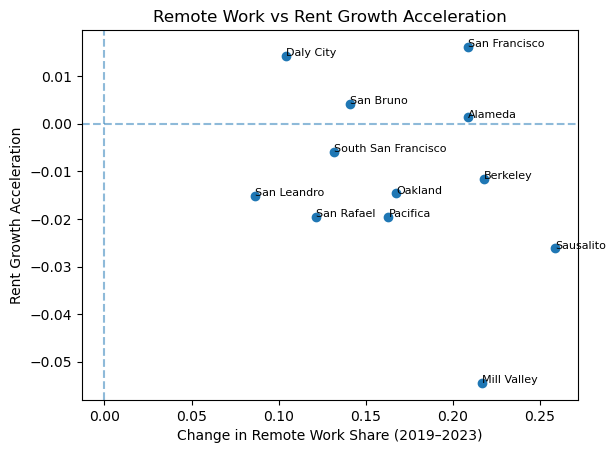

In [196]:
plt.figure()

plt.scatter(master['remote_work_growth'], 
            master['rent_growth_acceleration'])

for i, city in enumerate(master['city']):
    plt.text(master['remote_work_growth'][i],
             master['rent_growth_acceleration'][i],
             city, fontsize=8)

plt.xlabel('Change in Remote Work Share (2019–2023)')
plt.ylabel('Rent Growth Acceleration')
plt.title('Remote Work vs Rent Growth Acceleration')

plt.axhline(0, linestyle='--', alpha=0.5)
plt.axvline(0, linestyle='--', alpha=0.5)

plt.show()

The relationship between changes in remote work share and rent growth acceleration appears weak across cities. While we observed that remote work increased substantially between 2019 and 2023 in all locations, there is no clear linear pattern linking this increase to changes in rent growth. 

### Core Empirical Analysis

##### Baseline Model

In [197]:
baseline_model = sm.ols(formula='rent_growth_acceleration ~ baseline_rent_growth', data=master).fit()

print(baseline_model.summary())

                               OLS Regression Results                               
Dep. Variable:     rent_growth_acceleration   R-squared:                       0.838
Model:                                  OLS   Adj. R-squared:                  0.822
Method:                       Least Squares   F-statistic:                     51.81
Date:                      Wed, 06 May 2026   Prob (F-statistic):           2.93e-05
Time:                              12:51:59   Log-Likelihood:                 41.826
No. Observations:                        12   AIC:                            -79.65
Df Residuals:                            10   BIC:                            -78.68
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


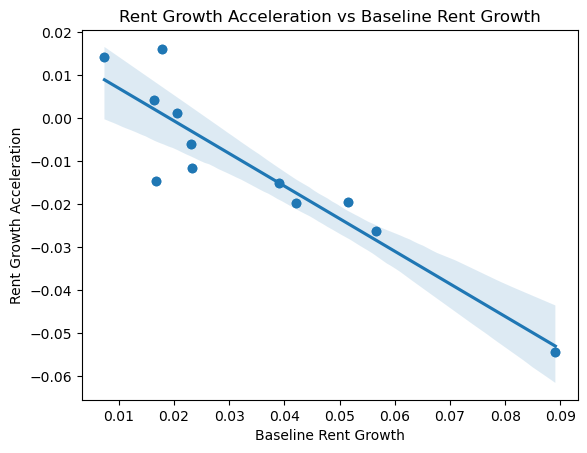

In [198]:
plt.scatter(master['baseline_rent_growth'], master['rent_growth_acceleration'])
sns.regplot(x='baseline_rent_growth', y='rent_growth_acceleration', data=master)
plt.xlabel('Baseline Rent Growth')
plt.ylabel('Rent Growth Acceleration')
plt.title('Rent Growth Acceleration vs Baseline Rent Growth')
plt.show()

The coefficient on baseline rent growth is -0.76, indicating that cities with higher pre-COVID rent growth tended to experience lower rent growth acceleration post-COVID. This negative relationship is also visible in the scatter plot, where higher higher baseline growth is associated with lower subsequent acceleration. 

##### Alternative Model

In [199]:
model2 = sm.ols('rent_growth_acceleration ~ baseline_rent_growth + total_housing_units + rent_to_income + log_income + remote_share_2019', data=master).fit( )
print(model2.summary())

                               OLS Regression Results                               
Dep. Variable:     rent_growth_acceleration   R-squared:                       0.884
Model:                                  OLS   Adj. R-squared:                  0.788
Method:                       Least Squares   F-statistic:                     9.161
Date:                      Wed, 06 May 2026   Prob (F-statistic):            0.00890
Time:                              12:51:59   Log-Likelihood:                 43.832
No. Observations:                        12   AIC:                            -75.66
Df Residuals:                             6   BIC:                            -72.75
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


Baseline rent growth is the only statistically significant feature in this final model. 
Its negative coefficient (-0.73) suggests that cities with higher pre-COVID rent growth tended to experience lower rent growth acceleration post-COVID, while cities with relatively stable or slower-growing rents pre-COVID saw larger increases afterward. 

After controlling for baseline trends, such as rent-to-income ratio, log median income, and total housing units do not have statistically significant effects on rent growth acceleration. This indicates that much of the variation in post-pandemic rent dynamics is explained by pre-existing trends rather than economic or housing characteristics. 

The model achieves a high R-squared of 0.884, indicating a strong fit to the observed data. However, this should also be interpreted with caution given the small sample size (N = 12), which may inflate goodness-of-fit and limit generalizability. 

Overall, the empirical analysis does not reveal a clear or robust relationship between remote work exposure, local economic conditions, and rent growth acceleration. Given these limitations, the next sections introduces a simulation framework to model the underlying mechanisms more directly and evaluate the potentiaal impact of a Dynamic Local Income Tax (DLIT) policy. 

### DLIT Simulation

To evaluate the potential impact of a Dynamic Local Income Tax (DLIT) on migration patterns and housing outcomes, I simulate household location decisions across Bay Area cities over a five-year period. The simulation compares two scenarios: a baseline with no policy intervention abd a DLIT scenario in which higher-income households are taxed when relocating to lower-income cities.

In the simulation, all households begin in San Francisco, and each month, a fixed share (2%) of residents consider relocating. Households chose their destination city by maximizing a utility function that depends on local amenities, rent levels, and any applicable taxes. 

Housing markets respond dynamically to these migration flows. As more households move into a city, increased demand places upward pressure on rents, while outflows reduce demand and slow rent growth. This feedback mechanism allows the simulation to capture how migration patterns and housing costs evolve jointly over time. 

In [200]:
city_df = master[['city', 'nov_2025_median_rent_price', 'median_household_income', 'total_housing_units', 'rent_to_income', 'remote_share_2019']]
city_df = city_df.rename(columns={
    'median_household_income': 'median_income', 
    'total_housing_units': 'housing_stock', 
    'nov_2025_median_rent_price': 'rent',})
city_df['amenity_score'] = city_df['remote_share_2019']
#make elasticity vary by city
city_df['elasticity'] = [
    2.0,  # Alameda
    1.8,  # Berkeley
    1.5,  # Daly City
    0.5,  # Mill Valley (very constrained)
    2.5,  # Oakland
    0.7,  # Pacifica
    1.2,  # San Bruno
    1.0,  # SF
    2.0,  # San Leandro
    1.3,  # San Rafael
    0.4,  # Sausalito (VERY constrained)
    1.5   # South SF
]
city_df

,city,rent,median_income,housing_stock,rent_to_income,remote_share_2019,amenity_score,elasticity
0,Alameda,2775.369222,132015,32129,0.252278,0.072605,0.072605,2.0
1,Berkeley,2920.797835,108558,52112,0.322865,0.107144,0.107144,1.8
2,Daly City,2729.278102,119570,35414,0.273909,0.023678,0.023678,1.5
3,Mill Valley,3949.851852,208466,6353,0.227367,0.155714,0.155714,0.5
4,Oakland,2457.896337,97369,187847,0.302917,0.066812,0.066812,2.5
5,Pacifica,3560.822222,156819,14596,0.272479,0.048758,0.048758,0.7
6,San Bruno,2929.895238,135976,16736,0.258566,0.026410,0.026410,1.2
7,San Francisco,3679.658922,141446,411542,0.312175,0.065977,0.065977,1.0
8,San Leandro,2387.844055,98063,32285,0.292201,0.041148,0.041148,2.0
9,San Rafael,3117.600119,109317,24212,0.342227,0.107583,0.107583,1.3


In [201]:
#synthetic households

n_households = 5000
households = pd.DataFrame({
    'household_id': range(n_households),
    'income': np.random.lognormal(mean=np.log(city_df['median_income'].mean()), sigma=0.5, size=n_households), 
    'current_city': 'San Francisco', 
    'months_since_move': 0})
households

,household_id,income,current_city,months_since_move
0,0,86168.511955,San Francisco,0
1,1,107182.770595,San Francisco,0
2,2,179740.418528,San Francisco,0
3,3,124841.165190,San Francisco,0
4,4,61008.310221,San Francisco,0
...,...,...,...,...
4995,4995,156982.133717,San Francisco,0
4996,4996,84117.581279,San Francisco,0
4997,4997,232260.561030,San Francisco,0
4998,4998,104220.991390,San Francisco,0


In [202]:
def compute_dlit(income, city_row, apply_dlit):
    if not apply_dlit:
        return 0.0
    median_income = city_row['median_income']
    r = income/median_income
    if r < 1:
        rate = 0.00
    elif r < 2:
        rate = 0.02
    elif r < 3:
        rate = 0.04
    else:
        rate = 0.06
    return rate * income

In [203]:
#adding crowding penalty -- when too many people move someplace, it becomes less attractive

def utility3(income, city_row, apply_dlit,
             beta_amenity=80,
             beta_rent=0.0002,
             beta_tax=0.0003,
             beta_crowding=50):

    tax = compute_dlit(income, city_row, apply_dlit)

    crowding = city_row['inflow'] / city_row['housing_stock']

   

    return (
    beta_amenity * city_row['amenity_score']
    - beta_rent * (city_row['rent'] / income)  
    - beta_tax * tax
    - beta_crowding * crowding
)


In [204]:
#probabilistic choice function

def softmax(x, temperature=1.0):
    x = np.array(x, dtype = float)
    x = x - np.max(x)
    exp_x = np.exp(x / temperature)
    return exp_x / np.sum(exp_x)

def choose_city(utilities, temperature = 5.0):
    utilities = np.array(utilities)
    exp_u = np.exp((utilities - np.max(utilities)) / temperature)
    probabilities = exp_u / np.sum(exp_u)
    return np.random.choice(len(utilities), p=probabilities)

In [205]:
#adjust alpha so rent adjusts to inflow
def run_simulation3(city_df, households, month=60, move_share=0.02, apply_dlit=False, alpha=0.30):
    city_state = city_df.copy()
    hh = households.copy()

    results = []

    for m in range(month):
        city_state['inflow'] = 0
        city_state['outflow'] = 0
        city_state['dlit_revenue'] = 0.0

        sf_households = hh[hh['current_city'] == 'San Francisco']
        n_movers = int(move_share * len(sf_households))

        if n_movers > 0:
            mover_ids = np.random.choice(
                sf_households['household_id'],
                size=n_movers,
                replace=False
            )

            for hid in mover_ids:
                income = hh.loc[hh['household_id'] == hid, 'income'].values[0]

                destination_options = city_state[city_state['city'] != 'San Francisco']

                utilities = []
                for _, row in destination_options.iterrows():
                    u = utility3(income, row, apply_dlit)
                    utilities.append(u)
            

                chosen_idx = choose_city(utilities, temperature=3.0)
                chosen_city = destination_options.iloc[chosen_idx]['city']
                chosen_row = destination_options.iloc[chosen_idx]

                hh.loc[hh['household_id'] == hid, 'current_city'] = chosen_city
                hh.loc[hh['household_id'] == hid, 'months_since_move'] = 0

                city_state.loc[city_state['city'] == chosen_city, 'inflow'] += 1
                city_state.loc[city_state['city'] == 'San Francisco', 'outflow'] += 1

                tax = compute_dlit(income, chosen_row, apply_dlit)
                city_state.loc[city_state['city'] == chosen_city, 'dlit_revenue'] += tax

        # rent update every month
        city_state['rent'] = city_state['rent'] * (
            1 + alpha * (city_state['inflow'] / city_state['housing_stock']) / city_state['elasticity']
        )

        # increment every month
        hh['months_since_move'] += 1

        # save every month
        snapshot = city_state.copy()
        snapshot['month'] = m + 1
        results.append(snapshot)

    return pd.concat(results, ignore_index=True), hh

In [206]:
baseline3_results, baseline3_households = run_simulation3(city_df, households, apply_dlit=False)
dlit3_results, dlit3_households = run_simulation3(city_df, households, apply_dlit=True)

In [207]:
baseline3_results['scenario'] = 'baseline'
dlit3_results['scenario'] = 'dlit'

dlit_model3_results = pd.concat([baseline3_results, dlit3_results], ignore_index=True)
dlit_model3_results.head(12)

,city,rent,median_income,housing_stock,rent_to_income,remote_share_2019,amenity_score,elasticity,inflow,outflow,dlit_revenue,month,scenario
0,Alameda,2775.434009,132015,32129,0.252278,0.072605,0.072605,2.0,5,0,0.0,1,baseline
1,Berkeley,2920.881908,108558,52112,0.322865,0.107144,0.107144,1.8,9,0,0.0,1,baseline
2,Daly City,2729.278102,119570,35414,0.273909,0.023678,0.023678,1.5,0,0,0.0,1,baseline
3,Mill Valley,3964.773376,208466,6353,0.227367,0.155714,0.155714,0.5,40,0,0.0,1,baseline
4,Oakland,2457.905757,97369,187847,0.302917,0.066812,0.066812,2.5,6,0,0.0,1,baseline
5,Pacifica,3561.135883,156819,14596,0.272479,0.048758,0.048758,0.7,3,0,0.0,1,baseline
6,San Bruno,2929.895238,135976,16736,0.258566,0.026410,0.026410,1.2,0,0,0.0,1,baseline
7,San Francisco,3679.658922,141446,411542,0.312175,0.065977,0.065977,1.0,0,100,0.0,1,baseline
8,San Leandro,2387.888431,98063,32285,0.292201,0.041148,0.041148,2.0,4,0,0.0,1,baseline
9,San Rafael,3117.778406,109317,24212,0.342227,0.107583,0.107583,1.3,6,0,0.0,1,baseline


In [208]:
baseline3_results.groupby(['month', 'city'])['inflow'].sum().reset_index()
baseline3_results[baseline3_results['month'] == 60][['city', 'inflow', 'outflow', 'rent']]

,city,inflow,outflow,rent
708,Alameda,0,0,2777.067135
709,Berkeley,4,0,2923.947552
710,Daly City,2,0,2729.925544
711,Mill Valley,13,0,4463.928606
712,Oakland,1,0,2458.103605
713,Pacifica,0,0,3567.519754
714,San Bruno,0,0,2931.515020
715,San Francisco,0,30,3679.658922
716,San Leandro,0,0,2388.665163
717,San Rafael,3,0,3128.434567


In [209]:
income = households['income'].iloc[0]

debug_city_df = city_df.copy()
debug_city_df['inflow'] = 0

destination_options = debug_city_df[debug_city_df['city'] != 'San Francisco']

debug = []

for _, row in destination_options.iterrows():
    debug.append({
        'city': row['city'],
        'tax_baseline': compute_dlit(income, row, apply_dlit=False),
        'tax_dlit': compute_dlit(income, row, apply_dlit=True),
        'utility_baseline': utility3(income, row, apply_dlit=False),
        'utility_dlit': utility3(income, row, apply_dlit=True)
    })

pd.DataFrame(debug).sort_values('utility_dlit', ascending=False)

,city,tax_baseline,tax_dlit,utility_baseline,utility_dlit
3,Mill Valley,0.0,0.0,12.457151,12.457151
9,Sausalito,0.0,0.0,11.644252,11.644252
8,San Rafael,0.0,0.0,8.606646,8.606646
1,Berkeley,0.0,0.0,8.571515,8.571515
0,Alameda,0.0,0.0,5.808401,5.808401
4,Oakland,0.0,0.0,5.344971,5.344971
5,Pacifica,0.0,0.0,3.900594,3.900594
7,San Leandro,0.0,0.0,3.291852,3.291852
10,South San Francisco,0.0,0.0,2.676979,2.676979
6,San Bruno,0.0,0.0,2.112775,2.112775


In [210]:
comparison = pd.DataFrame({
    'baseline_inflow': baseline3_results.groupby('city')['inflow'].sum(),
    'dlit_inflow': dlit3_results.groupby('city')['inflow'].sum()
})

comparison['difference'] = comparison['dlit_inflow'] - comparison['baseline_inflow']
comparison.sort_values('difference', ascending=False)

,baseline_inflow,dlit_inflow,difference
city,,,
Mill Valley,1297,1409,112
Sausalito,964,990,26
Pacifica,64,80,16
Daly City,42,43,1
San Bruno,37,38,1
San Francisco,0,0,0
South San Francisco,52,46,-6
Alameda,131,120,-11
San Leandro,74,58,-16


##### Simulation Results

The simulation compares migration patterns and rent dynamics under two scenarios: a baseline with no policy intervention and a DLIT scenario in which households may face a tax when relocating. The results show how policy can influence where households choose to move and how housing markets change over time

###### Migration Patterns

In the baseline scenario, households tend to relocate from San Francisco to nearby cities with lower rent levels. This produces consistent inflows into suburban cities and outflows from San Francisco. 
Under the DLIT scenario, the migration patterns shift. The tax reduces the utility of moving to certain citoes for high-income households, resulting in a redistribution of migration flows rather than a complete reduction of migration. 

###### Redistribution of Demand

The DLIT policy redirects migration rather than eliminate it. Cities such as Mill Valley, Sausalito, and South San Francisco become relatively more attractive under the policy, experiencing increased inflows compared to the baseline scenario. This shift reflects how the tax alters the relative utility across cities, making some previously less-preferred locations more competitive for relocating households. 

###### Rent Dynamics

Changes in migration patterns translate directly into differences in rent outcomes. In the baseline scenario, cities with the highest inflows experience the strongest rent increases due to increased demand. 

Under the DLIT scenario, cities that receive greater inflows (such as Mill Valley and Sausalito) also experience higher rent growth, while pressure in other cities is reduced. This highlights the endogenous relationshup between migration and housing costs -- policy-driven changes in location choice can redirect, rather than eliminate, rent pressures across markets. 

###### Policy Mechanism

The DLIT operates by reducing the utility of relocating for high-income households through a progressive tax. This mechanism primarily affects higher earners, altering their location decisions without directly restricting their movement. As a result, the policy influences housing outcomes indirectly through its effect on migration behavior rather than direct intervention in housing supply or pricing. 

While simplified, the simulation demonstrates how policy interventions can meaningfully alter the spatial distribution of demand in a remote work-enabled housing market. 

##### User Simulation

In addition to the baseline and DLIT scenarios, the simulation includes an interactive component that allows users to modify key parameters and observe how outcomes change. Users can adjust factors such as tax rates, rent sensitivity, and housing market responsiveness to explore how different assumptions influence migration patterns and rent dynamics. 

In [211]:
def compute_user_dlit(income, city_row, apply_dlit,
                 rate_1x=0.00,
                 rate_2x=0.02,
                 rate_3x=0.04,
                 rate_4x=0.06):

    if not apply_dlit:
        return 0.0

    median_income = city_row['median_income']
    income_ratio = income / median_income

    if income_ratio < 1:
        rate = rate_1x
    elif income_ratio < 2:
        rate = rate_2x
    elif income_ratio < 3:
        rate = rate_3x
    else:
        rate = rate_4x

    return rate * income

In [212]:
def run_user_simulation(city_df, households,
                        months=60,
                        move_share=0.02,
                        apply_dlit=False,
                        alpha=0.30,
                        beta_amenity=80,
                        beta_rent=20,
                        beta_tax=0.0003,
                        rate_2x=0.02,
                        rate_3x=0.04,
                        rate_4x=0.06,
                        beta_crowding=50,
                        temperature=3.0):

    def utility_user(income, city_row):
        tax = compute_user_dlit(income, city_row, apply_dlit, rate_2x=rate_2x, rate_3x=rate_3x, rate_4x=rate_4x )
        annual_rent_burden = 12 * city_row['rent'] / income
        # affordability constraint
        if annual_rent_burden > 0.40:
            return -1000
        crowding = city_row['inflow'] / city_row['housing_stock']

        return (
            beta_amenity * city_row['amenity_score']
            - beta_rent * annual_rent_burden
            - beta_tax * tax
            - beta_crowding * crowding
        )

    city_state = city_df.copy()
    hh = households.copy()
    results = []

    for m in range(months):
        city_state['inflow'] = 0
        city_state['outflow'] = 0
        city_state['dlit_revenue'] = 0.0

        sf_households = hh[hh['current_city'] == 'San Francisco']
        n_movers = int(move_share * len(sf_households))

        if n_movers > 0:
            mover_ids = np.random.choice(
                sf_households['household_id'],
                size=n_movers,
                replace=False
            )

            for hid in mover_ids:
                income = hh.loc[hh['household_id'] == hid, 'income'].values[0]
                destination_options = city_state[city_state['city'] != 'San Francisco']

                utilities = []
                for _, row in destination_options.iterrows():
                    utilities.append(utility_user(income, row))

                chosen_idx = choose_city(utilities, temperature=temperature)
                chosen_city = destination_options.iloc[chosen_idx]['city']
                chosen_row = destination_options.iloc[chosen_idx]

                hh.loc[hh['household_id'] == hid, 'current_city'] = chosen_city
                hh.loc[hh['household_id'] == hid, 'months_since_move'] = 0

                city_state.loc[city_state['city'] == chosen_city, 'inflow'] += 1
                city_state.loc[city_state['city'] == 'San Francisco', 'outflow'] += 1

                tax = compute_user_dlit(income, chosen_row, apply_dlit)
                city_state.loc[city_state['city'] == chosen_city, 'dlit_revenue'] += tax

        growth = alpha * np.log1p(city_state['inflow'] / city_state['housing_stock']) / city_state['elasticity']

        # cap monthly rent growth at 3%
        growth = np.minimum(growth, 0.03)

        city_state['rent'] = city_state['rent'] * (1 + growth)

        hh['months_since_move'] += 1

        snapshot = city_state.copy()
        snapshot['month'] = m + 1
        results.append(snapshot)

    return pd.concat(results, ignore_index=True), hh

In [213]:
user_months = int(input("How many months should the simulation run? "))
user_move_share = float(input("What share of SF households move each month? (0.005 - 0.05) "))
user_alpha = float(input("How strongly should inflow affect rent? (0.01 - 0.30)"))
user_apply_dlit = input("Apply DLIT? yes/no: ").lower() == "yes"

user_results, user_households = run_user_simulation(
    city_df,
    households,
    months=user_months,
    move_share=user_move_share,
    alpha=user_alpha,
    apply_dlit=user_apply_dlit
)

ValueError: invalid literal for int() with base 10: ''

In [ ]:
user_results[user_results['month'] == user_months][
    ['city', 'rent', 'inflow', 'outflow', 'dlit_revenue']
]

### Discussion

This analysis examined the relationship between remote work, migration patterns, and housing outcomes across Bay Area cities. While remote work expanded significantly following the COVID-19 pandemic, the empirical analysis finds little evidence of a strong, direct relationship between remote work adoption and rent growth acceleration. Instead, pre-existing rent trends appear to be the strongest predictor of post-pandemic rent dynamics. 

To further explore potenatial mechanisms, a simulation framework was developed to model how remote work-enabled migration interacts with local housing markets. The simulation results suggest that migration flows from San Francisco to surrounding cities can generate localized rent pressures, even in the absence of a strong aggregate statistical relationship. 

The weak empirical relationship between remote work and rent growth suggests that remote work alone does not directly determine housing outcomes. Instead, it acts as an enabling factor that expands the feasible set of residential choices for households. This helps explain why cities with similar increases in remote work experienced different rent outcomes. Local conditions, including housing supply constraints, baseline demand, and amenities, play a more important role in determining how migration translates into rent changes. 

The simulation results indicate that policies like DLIT can meaninfully influence migration patterns by altering incentives faced by higher-income households. The primary effect of the policy is to redistribute rent pressure across cities rather than eliminate it. By reducing the attractiveness of certain locations, the DLIT shifts migration flows toward alternative destinations, resulting in corresponding shifts in rent growth. This suggests that location-based policies may have unintended spillover effects, as reducing demand in one area can increase pressure in others. The targeted nature of the DLIT policy (focused on higher-income households) offers a mechanism to address displacement pressures without restricting mobility. 

Together, the empirical and simulation results highlight the complexity of housing market dynamics in the post-pandemic era. While the data does not support a direct relationship between remote work and rent growth, the simulation demonstrates how remote work-enabled mobility can still generate localized effects through migration flows. 

This analysis underscores that housing outcomes are shaped by the interaction of multiple factors, including income, housing supply constraints, and behavioral responses to policy. Remote work has enabled geographic flexibility, but its effects depend heavily on local market conditions and policy responses. As remote work continues to evolve, understanding these interactions will be critical for designing policies that promote housing affordability without shifting pressures to susceptible regions. 

### Limitations

1. Data and Sample Size:
This analysis is based on a small set of Bay Area cities, which limits the statistical power of the empirical results. With such a small sample size, regression estimates may be sensitive to outliers and may not generalize to other regions. Additionally, the analysis relies on aggregated city-level data, which masks variation within cities and across different types of households. 

2. Remote Work Measurement:
Remote work is proxied using ACS data on work-from-home share, which might not fully capture the complexity of remote work arrangements. For example, hybrid work is not directly observed, and may not be represented at all in either the in-office or remote work categories. As a result, the measure may not perfectly reflect the true extent of remote work adoption. 

3. Simplified Assumptions in the Simulation
The simulation relies on a simplified representation of household behavior and housing markets. Households are assumped to make moving decisions based on a simplified utility function based on rent, amenities, and tax costs, omitting other important factors such as social ties or life stage consideration. Additionally, the amenity variable is highly simplified and serves as a broad proxy for overall city attractiveness. Rather than being constructed from observed data (e.g., access to public transportation, school quality, safety, or proximity to retail/dining), amenity scores are assigned without using empirical measures and do not relfect the true characteristics of each city. Further, the model assumes that all households begin in San Francisco and that a fixed share of residents consider moving each month, While useful for isolating migration dynamics, these assumptions do not fully reflect real-world population distributions or mobility patterns. 

4. Temporal Alignment: 
The use of remote work data from 2023 alongside housing and economic variables measured in 2025 introduces potential measurement error, as remote work patterns may have continued to evolce between 2023 and 2025. While remote work stabilized after its rapid expansion during the pandemic, there have been shifts in remote work policies (ex: return to office mandates & hybrid adjustments) that can affect the true level of remote work exposure in each city by 2025. However, using 2023 data still provides a reasonable proxy for post-pandemic remote work patterns, as it reflects a period after the initial shock when remote work adoption had largely stabilized relative to levels before and during the pandemic. As a result, the 2023 remote work share may not perfectly capture the conditions influencing housing demands in the later period. 


### Conclusion

This analysis examines the impact of the rise of remote work on migration patterns and housing outcomes in the San Francisco Bay Area. Despite the fact that remote work expanded rapidly during the COVID-19 pandemic, there is little evidence that it had an affect on rent growth acceleration. 

However, the simulation results suggest that remote work-enabled migration can still generate localized rent pressure through shifting demand across cities. Policies such as the Dynamic Local Income Tax (DLIT) can influence these dynamics by altering migration incentives, though its primary effect is to redistribute housing pressure rather than eliminate it. 

Overall, these findings highlight that housing outcomes in the post-pandemic era are shaped less by remote work alone and more by how it interacts with local market conditions and policy responses. 